Purpose.

Part A: To classify iris flower species based on sepal and petal measurements using machine learning models (Decision Tree and KNN) and compare their performance.

/Users/chadmutinda/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Decision Tree Metrics:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00



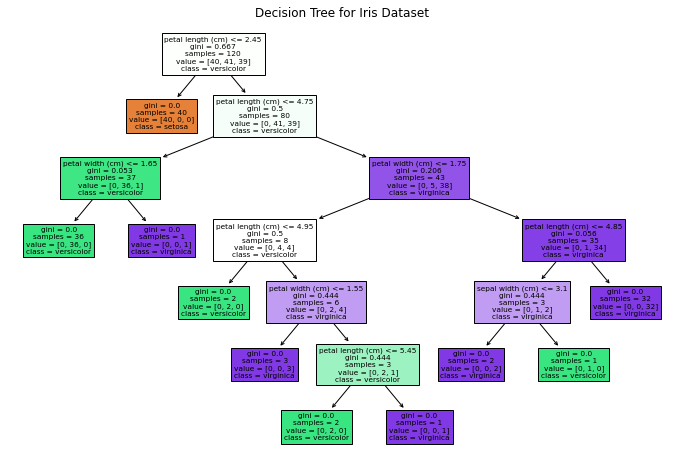

KNN Metrics:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Both classifiers performed equally well.

Detailed Classification Reports:
Decision Tree:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

KNN:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
# Part A: Classification using Iris Dataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

# 1. Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------- Decision Tree Classifier -----------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Compute metrics for Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree Metrics:")
print(f"Accuracy: {accuracy_dt:.2f}")
print(f"Precision: {precision_dt:.2f}")
print(f"Recall: {recall_dt:.2f}")
print(f"F1 Score: {f1_dt:.2f}\n")

# Visualize Decision Tree
plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Decision Tree for Iris Dataset")
plt.show()

# ----------- KNN Classifier (k=5) -----------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Compute metrics for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN Metrics:")
print(f"Accuracy: {accuracy_knn:.2f}")
print(f"Precision: {precision_knn:.2f}")
print(f"Recall: {recall_knn:.2f}")
print(f"F1 Score: {f1_knn:.2f}")

# ----------- Comparison -----------
if accuracy_dt > accuracy_knn:
    print("\nDecision Tree performed better.")
elif accuracy_knn > accuracy_dt:
    print("\nKNN performed better.")
else:
    print("\nBoth classifiers performed equally well.")

print("\nDetailed Classification Reports:")
print("Decision Tree:\n", classification_report(y_test, y_pred_dt, target_names=iris.target_names))
print("KNN:\n", classification_report(y_test, y_pred_knn, target_names=iris.target_names))


Purpose.

Part A: To classify iris flower species based on sepal and petal measurements using machine learning models (Decision Tree and KNN) and compare their performance.

In [15]:
import random
from itertools import combinations

# Step 1: Generate synthetic transaction data
items_pool = ['milk', 'bread', 'beer', 'diapers', 'eggs', 'butter', 'cheese', 'apples', 'bananas', 'oranges',
              'chicken', 'rice', 'pasta', 'yogurt', 'juice', 'coffee', 'tea', 'sugar', 'salt', 'flour']

random.seed(42)
transactions = [random.sample(items_pool, random.randint(3, 8)) for _ in range(30)]

print("Sample Transactions:")
for t in transactions[:5]:
    print(t)

# Step 2: Function to compute support
def get_support(itemset, transactions):
    count = sum(1 for t in transactions if itemset.issubset(set(t)))
    return count / len(transactions)

# Step 3: Generate frequent itemsets
def apriori(transactions, min_support):
    items = set(i for t in transactions for i in t)
    itemsets = [frozenset([i]) for i in items]
    frequent_itemsets = []
    
    while itemsets:
        valid_itemsets = []
        for itemset in itemsets:
            support = get_support(itemset, transactions)
            if support >= min_support:
                frequent_itemsets.append((itemset, support))
                valid_itemsets.append(itemset)
        itemsets = [i.union(j) for i in valid_itemsets for j in valid_itemsets if len(i.union(j)) == len(i) + 1]
        itemsets = list(set(itemsets))
    
    return frequent_itemsets

# Step 4: Generate association rules
def generate_rules(frequent_itemsets, transactions, min_confidence):
    rules = []
    for itemset, support in frequent_itemsets:
        if len(itemset) >= 2:
            for i in range(1, len(itemset)):
                for antecedent in combinations(itemset, i):
                    antecedent = frozenset(antecedent)
                    consequent = itemset - antecedent
                    conf = get_support(itemset, transactions) / get_support(antecedent, transactions)
                    lift = conf / get_support(consequent, transactions)
                    if conf >= min_confidence:
                        rules.append((antecedent, consequent, support, conf, lift))
    return rules

# Step 5: Run Apriori
min_support = 0.2
min_confidence = 0.5

frequent_itemsets = apriori(transactions, min_support)
rules = generate_rules(frequent_itemsets, transactions, min_confidence)

# Step 6: Sort by lift and display top 5 rules
rules_sorted = sorted(rules, key=lambda x: x[4], reverse=True)[:5]

print("\nTop 5 Rules (Antecedent -> Consequent):")
for antecedent, consequent, support, confidence, lift in rules_sorted:
    print(f"{set(antecedent)} -> {set(consequent)}, Support: {support:.2f}, Confidence: {confidence:.2f}, Lift: {lift:.2f}")

# Example rule analysis
best_rule = rules_sorted[0]
print("\nExample Rule Analysis:")
print(f"If customers buy {set(best_rule[0])}, they are likely to also buy {set(best_rule[1])} "
      f"with a confidence of {best_rule[3]:.2f} and a lift of {best_rule[4]:.2f}.")


Sample Transactions:
['diapers', 'milk', 'bananas', 'apples', 'tea', 'beer', 'rice', 'bread']
['sugar', 'beer', 'yogurt', 'bread', 'milk', 'tea', 'diapers', 'flour']
['flour', 'milk', 'sugar', 'cheese', 'yogurt', 'diapers', 'apples']
['bananas', 'milk', 'butter', 'yogurt', 'chicken', 'eggs', 'beer']
['chicken', 'diapers', 'beer', 'pasta']

Top 5 Rules (Antecedent -> Consequent):
{'sugar'} -> {'beer'}, Support: 0.20, Confidence: 0.67, Lift: 1.67
{'beer'} -> {'sugar'}, Support: 0.20, Confidence: 0.50, Lift: 1.67
{'eggs'} -> {'bananas'}, Support: 0.20, Confidence: 0.75, Lift: 1.61
{'rice'} -> {'bananas'}, Support: 0.20, Confidence: 0.60, Lift: 1.29
{'beer'} -> {'diapers'}, Support: 0.20, Confidence: 0.50, Lift: 1.15

Example Rule Analysis:
If customers buy {'sugar'}, they are likely to also buy {'beer'} with a confidence of 0.67 and a lift of 1.67.


/Users/chadmutinda/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
